## CS 598 PSL Fall 2026
### Coding Assignment 2

- Anirudh Eswara
- Ryan Lenea
- Mark Synowiec
- Robert Walker

### Problem 1 [50 points]

In this problem, we are going to use a simulated example to illustrate the behavior of testing and training errors as the number of predictor increases.

(a) [5 points] Generate a data set with p = 20 (independent) covariates, n = 1,000 observations and an associated quantitative response vector generated according to the model

$Y = Xβ + ε$ with

$β = (2, −1, 0, 0.8, 0, −1.5, 1.2, 0, 0, 0.3, −0.7, 0, 1.8, 0, 0.5, 0, −1.2, 0, 0.4, 0)$

The covariates and the ε can be generated using standard normal random variables. (This
is similar to what you did in Coding Assignment # 1).

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

RANDOM_SEED = 598
n = 1000

rng = np.random.default_rng(RANDOM_SEED)
X = rng.standard_normal((n, 20))
df = pd.DataFrame(X, columns=[f'X{i}' for i in range(1, 21)])

beta = np.array([2, -1, 0, 0.8, 0, -1.5, 1.2, 0, 0, 0.3, -0.7, 0, 1.8, 0, 0.5, 0, -1.2, 0, 0.4, 0])
eps = rng.standard_normal(n)
y = X @ beta + eps



(b) [5 points] Randomly split the data set into a training set containing 200 observations and a test set containing 800 observations.

In [2]:
# split data int 200 training and 800 test observations
x_train, x_test, y_train, y_test = train_test_split(df, y, train_size=200, random_state=RANDOM_SEED)

(c) [10 points] Perform best subset selection on the training set, and plot the training set MSE associated with the best model of each size. Recall that

$MSE = {\frac 1 n} \sum\limits_{i=1}^n (y_i − \hat{y}_i)^2$

In [3]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X_tr = x_train.values
X_te = x_test.values

best_models = []
for k in range(1, 21):
    if k == 20:
        cols = list(range(X_tr.shape[1]))
    else:
        selector = SequentialFeatureSelector(
            LinearRegression(),
            n_features_to_select=k,
            direction="forward",
            scoring="neg_mean_squared_error",
            n_jobs=-1,
        ).fit(X_tr, y_train)
        # Which features we should use
        cols = selector.get_support(indices=True).tolist()

    # Actually fit a model with the features determined
    model = LinearRegression().fit(X_tr[:, cols], y_train)
    train_mse = mean_squared_error(y_train, model.predict(X_tr[:, cols]))
    test_mse = mean_squared_error(y_test, model.predict(X_te[:, cols]))
    best_models.append((cols, model, train_mse, test_mse))

(d) 10 points] Plot the test set MSE associated with the best model of each size.

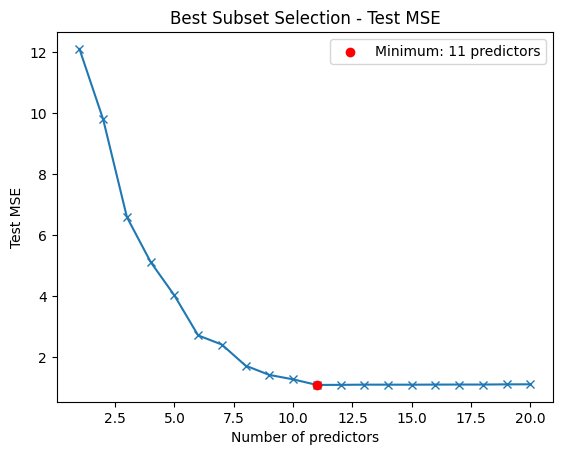

In [4]:
test_mses = [e[3] for e in best_models]
best_size = np.argmin(test_mses) + 1
best_test_mse = test_mses[best_size - 1]

plt.plot(range(1, 21), test_mses, marker="x")
plt.scatter(best_size, best_test_mse, color="red", zorder=3, label=f"Minimum: {best_size} predictors")
plt.xlabel("Number of predictors")
plt.ylabel("Test MSE")
plt.title("Best Subset Selection - Test MSE")
plt.legend()
plt.show()


(e) [5 points] For which model size does the test set MSE take on its minimum value? Comment on your results.

Remark: If it takes on its minimum value for a model containing only an intercept or a model containing all of the features, then play around with the way that you are generating the data in (a) until you come up with a scenario in which the test set MSE is minimized for an intermediate model size.

In [8]:
train_mses = [e[2] for e in best_models]
for i, m in enumerate(best_models):
    print(f"For {i + 1} feature(s), train MSE {m[2]} {">=" if m[2] >= m[3] else "<"} test MSE {m[3]}")
display(best_models[best_size - 1])

For 1 feature(s), train MSE 13.519168012518936 >= test MSE 12.116339203268282
For 2 feature(s), train MSE 10.290785663612365 >= test MSE 9.803435739052999
For 3 feature(s), train MSE 7.390213430183382 >= test MSE 6.59978191342308
For 4 feature(s), train MSE 5.648593347954984 >= test MSE 5.126624779844722
For 5 feature(s), train MSE 4.0558522707826645 >= test MSE 4.032643967836523
For 6 feature(s), train MSE 2.877619905408516 >= test MSE 2.7208531828858837
For 7 feature(s), train MSE 2.127817004201061 < test MSE 2.4194961821076415
For 8 feature(s), train MSE 1.5125371170411257 < test MSE 1.7271395427346277
For 9 feature(s), train MSE 1.204258604756896 < test MSE 1.4236206854955684
For 10 feature(s), train MSE 1.067624825690797 < test MSE 1.2782297161468565
For 11 feature(s), train MSE 0.9413033040599443 < test MSE 1.0953046133499078
For 12 feature(s), train MSE 0.9333008994504933 < test MSE 1.0972362515230147
For 13 feature(s), train MSE 0.9295447578972268 < test MSE 1.104218969000586
F

([0, 1, 3, 5, 6, 9, 10, 12, 14, 16, 18],
 LinearRegression(),
 0.9413033040599443,
 1.0953046133499078)

#### Comments on results:

For subsets of 6 features and less, the test set MSE was less than the training set MSE, though the test set MSE was minimized at 11 features. The training set MSE, however, was minimized only when using all available features in the dataset. The MSE was high for both with few features because the model was underfitted. This correlates with how the data was generated because out of the 20 initial random features, only 11 were used to generate y. At the top end where the model used all 20 features, the training set MSE being lower than the test set MSE, while the test set MSE increases past 11, shows that the model was overfitted to the training data. Past the optimal number of features, 11, the training set MSE shows a drastically reduced reduction in MSE, showing diminishing gains due to incorporation of noise from features unrelated to y.

(f) [5 points] How does the model at which the test set MSE is minimized compare to the true model used to generate the data? Comment on the coefficient values.

In [17]:
print("Betas used to generate y:")
print(best_models[best_size - 1][0])
print(beta[best_models[best_size - 1][0]])

for i, m in enumerate(best_models):
    if i == best_size - 1:
        print("Model with lowest test MSE:")
    print(f"{i + 1} feature(s) used: {best_models[i][0]}")
    print(beta[best_models[i][0]])
    print(best_models[i][1].coef_)

Betas used to generate y:
[0, 1, 3, 5, 6, 9, 10, 12, 14, 16, 18]
[ 2.  -1.   0.8 -1.5  1.2  0.3 -0.7  1.8  0.5 -1.2  0.4]
1 feature(s) used: [0]
[2.]
[1.73322601]
2 feature(s) used: [0, 5]
[ 2.  -1.5]
[ 1.78853486 -1.79228847]
3 feature(s) used: [0, 5, 12]
[ 2.  -1.5  1.8]
[ 1.76969399 -1.93206572  1.71425107]
4 feature(s) used: [0, 5, 12, 16]
[ 2.  -1.5  1.8 -1.2]
[ 1.75980013 -1.78049214  1.83491602 -1.2911485 ]
5 feature(s) used: [0, 1, 5, 12, 16]
[ 2.  -1.  -1.5  1.8 -1.2]
[ 1.89520305 -1.39361703 -1.76689831  1.89341207 -1.29997022]
6 feature(s) used: [0, 1, 5, 6, 12, 16]
[ 2.  -1.  -1.5  1.2  1.8 -1.2]
[ 1.93541144 -1.34465683 -1.55536202  1.13766801  1.87887914 -1.30458499]
7 feature(s) used: [0, 1, 5, 6, 10, 12, 16]
[ 2.  -1.  -1.5  1.2 -0.7  1.8 -1.2]
[ 1.87174281 -1.37359148 -1.49464044  1.25040532 -0.86018331  1.88556692
 -1.30985384]
8 feature(s) used: [0, 1, 3, 5, 6, 10, 12, 16]
[ 2.  -1.   0.8 -1.5  1.2 -0.7  1.8 -1.2]
[ 1.94455513 -1.26897586  0.82498343 -1.53224049  1.2

#### Comments on MSE:

The resultant $\hat{\beta}$'s closely resembled the ${\beta}$'s used to generate y. Interestingly, as features were added up to 11, only features used to initially generate y were consecutively added, meaning up until the optimal feature set, only meaningful features selected. This makes sense since the features that correlate with y would have the biggest impact on minimizing the test MSE. Also, while not completely consistent, the features selected below the optimal 11 features tended to be the those with the largest magnitude of beta when generating y. So for a single feature, feature 0 was selected with a beta of 2.0, followed by feature 5 which was added, with a beta of -1.5. This general trend continued, with the last feature added at the 11 feature set being 18 which had one of the smallest non-zero beta magnitudes (0.4).

This exercise highlighted the imporance and impact of relevant features vs the side effect of irrelevant features decreasing performance with the test set.

(g) [10 points] Create a plot displaying

$\sqrt{\sum\limits_{i=1}^n (\beta_j − \hat{\beta}^r_j)^2}$

for a range of values of r, where $\hat{\beta}^r_j$ is the jth coefficient estimate for the best model containing r coefficients. Comment on what you observe. How does this compare to the test MSE plot from (d)?

In [14]:
# Mark TODO - create a plot

TODO - comment on observations

### Problem 2 [50 points – 10 points each]

We will use the [Parkinsons Telemonitoring data set](https://doi.org/10.24432/C5ZS3N) from the UCI Machine Learning Repository.

The data contain 5,875 biomedical voice measurements from 42 patients with early-stage Parkinson’s disease. The goal is to predict a textitpatient’s disease severity (UPDRS score) from a collection of voice measures and a few demographic variables.

You should use the following variables as predictors:

| Variable | Description |
| ----------- | ----------- |
| `age` | Subject age |
| `sex` | Subject gender (0 = male, 1 = female) |
| `test-time` | Days since recruitment into the trial |
| `Jitter(%), Jitter(Abs)`<br>`Jitter:RAP, Jitter:PPQ5, Jitter:DDP` | Measures of variation<br>in fundamental frequency |
| `Shimmer, Shimmer(dB), Shimmer:APQ3`<br>`Shimmer:APQ5, Shimmer:APQ11, Shimmer:DDA` | Measures of variation in<br>amplitude |
| `NHR, HNR` | Noise-to-tonal component ratios |
| `RPDE` | Nonlinear dynamical complexity measure |
| `DFA` | Signal fractal scaling exponent |
| `PPE` | Nonlinear measure of fundamental frequency variation |

Response: total UPDRS – clinician’s total UPDRS score, linearly interpolated.

Data preparation: Download the data, remove the columns `subject#` and `motor_UPDRS`, and create a random 70 % / 30 % train–test split. Set the random seed to 598.


In [15]:
# first, pip install ucimlrepo

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
parkinsons_telemonitoring = fetch_ucirepo(id=189) 
  
# data (as pandas dataframes) 
X = parkinsons_telemonitoring.data.features 
y = parkinsons_telemonitoring.data.targets 
  
# metadata 
print(parkinsons_telemonitoring.metadata) 
  
# variable information 
print(parkinsons_telemonitoring.variables) 


{'uci_id': 189, 'name': 'Parkinsons Telemonitoring', 'repository_url': 'https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring', 'data_url': 'https://archive.ics.uci.edu/static/public/189/data.csv', 'abstract': "Oxford Parkinson's Disease Telemonitoring Dataset", 'area': 'Health and Medicine', 'tasks': ['Regression'], 'characteristics': ['Tabular'], 'num_instances': 5875, 'num_features': 19, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['motor_UPDRS', 'total_UPDRS'], 'index_col': ['subject#'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5ZS3N', 'creators': ['Athanasios Tsanas', 'Max Little'], 'intro_paper': {'ID': 229, 'type': 'NATIVE', 'title': "Accurate Telemonitoring of Parkinson's Disease Progression by Noninvasive Speech Tests", 'authors': 'A. Tsanas, Max A. Little, P. McSharry, L. Ramig', 'venue': 'IEEE Transactions on Bio

(a) Fit a best-subset selection algorithm (up to 8 predictors, excluding the intercept) and report the best model of each size together with its training and test prediction errors (MSE). Keep the output concise.

In [16]:
# Liam TODO - fit up to 8 predictors

(b) Using the models from (a), which model is preferred by (i) AIC, (ii) BIC, (iii) Mallows’ $C_p$, and (iv) adjusted $R^2$? For each of these four chosen models report both the training and the test MSE.

In [17]:
# Liam TODO - for each model report training and test MSE

TODO - determine which model is preferred for the above models

(c) Fit a ridge-regression model to predict `total_UPDRS`. Use cross-validation to select the regularization parameter λ.

In [18]:
# Liam or Anirudh TODO - fit ridge regression

(d) Fit a lasso model on the same data. Identify which features are driven to exactly zero.

In [19]:
# Anirudh TODO - fit lasso model

(e) Compare the predictive performance (test MSE) of the models selected in (b) with ridge and with lasso. Which approach would you recommend for predicting total UPDRS and why?

Anirudh TODO - recommendation for ridge vs lasso